### Lookup Tables
Until now we have performed what we call "live" calculations.
This means that at each epoch of interest we have requested the spacecraft position, attitude, the position of the sun, the spacecraft distance from the Sun, etc. 

For some calculations, e.g., involving tight time sampling, or when computing planetary radiation (see below) this approach might just be too computationally expensive to be acceptable. 
This is why we introduce the concept of the _Lookup Table of Normalized Geometry Vectors_  (**LUT**)

The fundamental concept behind it is that since we can write radiative accelerations as:

<center> $\vec{a} = \frac{k}{c} \, \mathbb{L}(\alpha, \delta)$ </center>


Where $k$ depends on the specific acceleration we are computing and $c$ is the speed of light (e.g., $\Phi/mc$ for solar radiation pressure) and $\mathbb{L}$ is what we define as the _geometry vector_.

The geometry vector depends only on the shape of the spacecraft, its thermo-optical properties and the incoming direction of a photon/ray (described through a righ ascension, $\alpha$ and declination $\delta$). 

Once the LUT is computed, we ideally can just plug it in pyRTX and compute the accelerations we need. 


### Computing the LUT
The computation of the LUT is conceptually simple: 
we want to predict all the possible attitudes that the spacecraft will undergo with respect to the radiation source and have the corresponding geometry vectors computed and written down. 
When actually computing the acceleration we will just interpolate the LUT to the requested attitude. 

Note that here the "attitude" concept is quite general. 
Say that you have a cylindrical spacecraft orbiting a planet and its long axis is nadir-oriented. Then the $\alpha$ and $\delta$ of the Sun in the body-fixed frame will change along the orbit. Thus one can pre-compute the expected range of $\alpha$ and $\delta$ and compute the LUT on this range

There are, of course, more complex examples.
Think, for example, of a spacecraft with moving parts. 
Then in that case one must create the LUT spanning not only the $\alpha$ and $\delta$ angles, but also all possible configurations of the moving appendages. 

Let's start with a simple example (they cylindrical spacecraft)

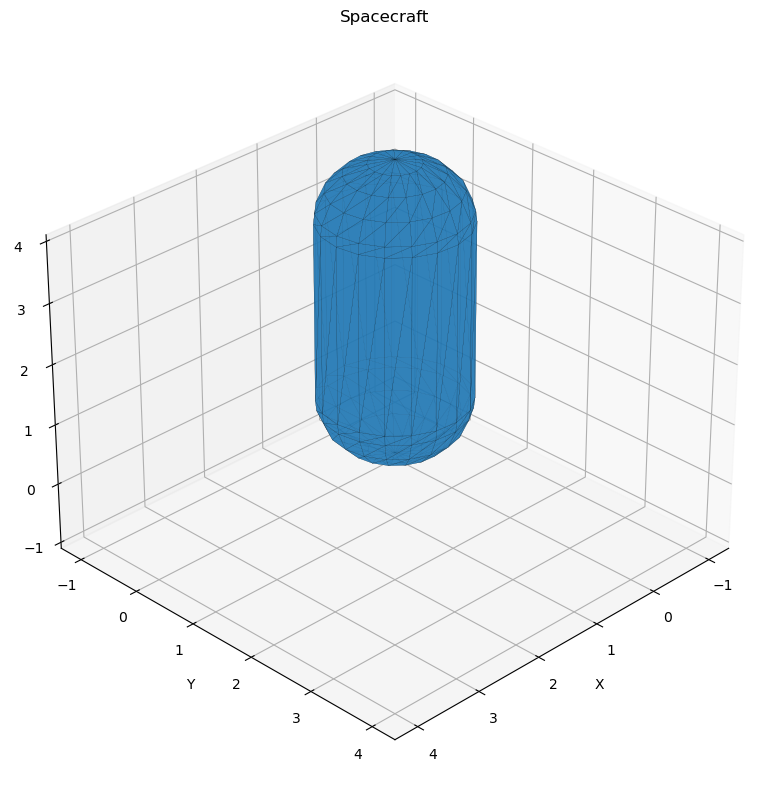

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh as tm
from pyRTX.visual.utils import plot_mesh
from pyRTX.classes.SRP import SolarPressure
from pyRTX.classes.Spacecraft import Spacecraft
from pyRTX.classes.PixelPlane import PixelPlane
from pyRTX.classes.RayTracer import RayTracer
import itertools
import xarray as xr

# Create a simple spacecraft (a capsule/cylinder)
sc = tm.creation.capsule(height = 3, radius = 1, count = [9,9], )
plot_mesh(sc, title = 'Spacecraft');

In [2]:
# We need to create the spacecraft object
sc_model = {
    'BUS':{
    'file' : sc,
    'frame_type': 'UD',
    'frame_name': 'BUS_FRAME',
    'UD_rotation' : tm.transformations.identity_matrix(),
    'center' : [0,0,0], 
    'specular': 0.3, 
    'diffuse' : 0,
    }}

sc_object = Spacecraft(
                name = 'Capsule', 
                base_frame = 'BUS_FRAME', 
                mass = 1, # NOTE: here the mass is 1 because we want to compute the LUT 
                spacecraft_model = sc_model, 
                units = 'm')


After having defined the spacecraft, we need to define the ranges of angles that we will be analyzing. For simplicity let's say that we expect the spacecraft to "see" the Sun in every possible configuration: i.e., alpha in $[0, 2\pi]$ and delta in $[-\pi/2, \pi/2]$ 

In [3]:
# One of the most important design parameters is the grid resolution
# For now let's set the sampling at 10 degrees
grid_res = 10 * np.pi/180 # radians

RA = np.linspace(0, 2*np.pi, int(2*np.pi/grid_res) + 1)
DEC = np.linspace(-np.pi/2, np.pi/2, int(np.pi/grid_res)+1)



In [4]:
# Now we have to define the pixel plane and the ray tracer
rays = PixelPlane(
        spacecraft = sc_object, 
        mode = 'Fixed', 
        width = 15, 
        height = 15, 
        ray_spacing = 0.1, 
        lon = 0, 
        lat = 0, 
        distance = 30,
        units = 'm', )


rtx = RayTracer(
        sc_object, 
        rays, 
        kernel = 'Embree3', 
        bounces = 1, 
        diffusion = False, 
)

# And define the solar pressure object
srp = SolarPressure(sc_object, rtx, baseflux = None)

You'll have possibly noticed a couple of strange things: 
1) The mass of the spacecraft is 1
2) The flux of the Sun is None

These settings are related to our goal of computing the LUT. 
Indeed we want only to compute the geometry vector, so if you look at the equation at the beginning of this notebook, we know that the Solar Pressure is computed as
<center>$\frac{\Phi}{mc} \mathbb{L}$</center>
So, we need to set $m$ and $\Phi$ to unit values to get $\mathbb{L}$. 

Now, what is left to do is to compute the LUT!

In [5]:
# Define an attribute dictionary for the LUT
axes = []
dims = []

axes.append(RA)
axes.append(DEC)
dims.append('ra')
dims.append('dec')
dims.append('value')


attrs = {
    'base_frame' : 'BUS_FRAME', 
    'type' : 'accel',
    'ref_epoch' : 'None', 
    'dims' : ",".join(dims), 
    # These are needed when there are moving parts. 
    # It will be discussed in a later example
    'eul_set' : '1,2,3',  
    'moving_frames' : '', 
}


shape = tuple([len(r) for r in axes] + [3])
coords = {dims[i]: vals for i, vals in enumerate(axes)}

print(f'\n *** LUT size: {shape} ...')
lut = np.empty(shape)


 *** LUT size: (37, 19, 3) ...


In [6]:
for ir, ra in enumerate(RA):
    for ide, dec in enumerate(DEC):
        srp.rayTracer.rays.update_latlon(lon = ra, lat = dec)
        value = np.squeeze(srp.compute([None]))
        lut[ir, ide] = value

In [7]:
# And transform it in an xarray for easier manipulation
LUT = xr.Dataset(data_vars = {'look_up_table' : (dims, lut)}, 
                 coords = coords, 
                 attrs = attrs)

print(LUT)

<xarray.Dataset>
Dimensions:        (ra: 37, dec: 19, value: 3)
Coordinates:
  * ra             (ra) float64 0.0 0.1745 0.3491 0.5236 ... 5.934 6.109 6.283
  * dec            (dec) float64 -1.571 -1.396 -1.222 ... 1.222 1.396 1.571
Dimensions without coordinates: value
Data variables:
    look_up_table  (ra, dec, value) float64 -7.063e-15 -1.224e-14 ... -1.021e-11
Attributes:
    base_frame:     BUS_FRAME
    type:           accel
    ref_epoch:      None
    dims:           ra,dec,value
    eul_set:        1,2,3
    moving_frames:  


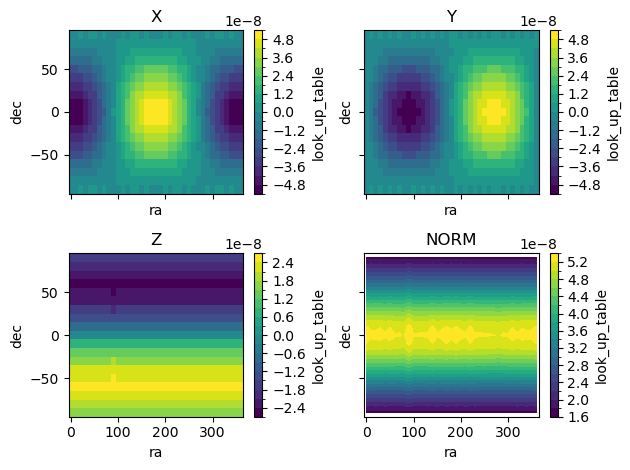

In [8]:
# The LUT is computed! We can inspect it by plotting the acceleration over different directions
# First adjust the coordinates to be in degrees, for easier visualization
LUT1 = LUT.assign_coords(
    ra=np.rad2deg(LUT['ra']),
    dec=np.rad2deg(LUT['dec'])
)

# To see what the SRP acceleration would look like, let's multiply the geometry
# vector by phi/m and convert to m/s2
phi = 1670
m = 1000

LUT1 = LUT1 * phi/m * 1000


fig, ax = plt.subplots(2,2, sharex = True, sharey = True)
ax = ax.reshape(-1)
for i in range(3):
    LUT1['look_up_table'].isel(value = i).plot(ax = ax[i],x='ra', y='dec', levels=20, cmap='viridis',)

norm_data = xr.apply_ufunc(
    np.linalg.norm,
    LUT1['look_up_table'],
    input_core_dims=[['value']],  # Specify which dimension to operate on
    kwargs={'axis': -1}
)

norm_data.plot.contourf(x='ra', y='dec', levels=20, cmap='viridis', ax=ax[-1])

ax[0].set_title('X')
ax[1].set_title('Y')
ax[2].set_title('Z')
ax[3].set_title('NORM')
plt.tight_layout()


Now that we have computed the LUT we can see how it can be useful. 


**Note** that in this case the calculation was simple/fast on purpose (to make this example runnable in a reasonable amount of time). 
Typical cases (e.g., with complex shapes and moving appendages) require much more time, and some additional coding effort (e.g., parallelization). 
You can find a full, in-depth, example of the computation of the LUT for Lunar Reconnaissance Orbiter in the `examples` folder (`examples/compute_lut.py`)

In a normal case one would save the LUT to a file for later use. 
The preferred format for pyRTX is NetCDF

In [9]:
LUT.to_netcdf('capsule_lut.nc', encoding = LUT.encoding.update({'zlib': True, 'complevel': 1}))




To make the example realistic, we will assume that the spacecraft for which we have computed the LUT is Lunar Reconnaissance Orbiter. This way we can take advantage of the kernels (trajectory, etc) that we have used in the previous examples.

In [10]:
# Let's see how to use the LUT now! 
# pyRTX exposes a class specifically thought to work with LUTs
from pyRTX.classes.LookUpTable import LookUpTable 
from pyRTX.classes.Planet import Planet
from pyRTX.classes.SRP import SunShadow, SolarPressure 
from pyRTX.classes.Precompute import Precompute
import spiceypy as sp
from pyRTX.core.analysis_utils import epochRange2
import timeit

METAKR = '../example_data/LRO/metakernel_lro.tm'     # metakernel
sp.furnsh(METAKR)  # Load the metakernel containing references to the necessary SPICE frames

lut = LookUpTable('capsule_lut.nc')

In [11]:
# Define timespan
ref_epc  = "2010 may 10 09:25:00"
duration = 10000  	
timestep = 100
epc_et0  =  sp.str2et( ref_epc ) 
epc_et1  = epc_et0 + duration
epochs   = epochRange2(startEpoch = epc_et0, endEpoch = epc_et1, step = timestep)

# Define spacecraft object
sc_model = {
    'BUS':{
    'file' : sc,
    'frame_type': 'Spice',
    'frame_name': 'LRO_SC_BUS',
    'center' : [0,0,0], 
    'specular': 0.3, 
    'diffuse' : 0,
    }}

lro = Spacecraft(
                name = 'LRO', 
                base_frame = 'LRO_SC_BUS', 
                mass = 2000,
                spacecraft_model = sc_model, 
                units = 'm')


# Define the Moon object
moon = Planet(  fromFile      = None,
                radius        = 1737.4,
                name          = 'Moon',
                bodyFrame     = 'MOON_PA',
                sunFixedFrame = 'GSE_MOON',
                units         = 'km',
                subdivs       = 5,
                )

# Precomputation object. This object performs all the calls to spiceypy before 
# calculating the acceleration. 
prec = Precompute(epochs = epochs,)
prec.precomputeSolarPressure(lro, moon, correction='LT+S')
prec.dump()

# Define the shadow function object
shadow = SunShadow( spacecraft     = lro,
				    body           = 'Moon',
				    bodyShape      = moon,
				    limbDarkening  = 'Eddington',
        			precomputation = prec,
				    )

# Define the solar pressure object (LUT mode)
srp = SolarPressure( lro, 
				     rayTracer      = None, # None because everything has been computed in advance
				     baseflux       = 1361.8,   
				     shadowObj      = shadow,
					 precomputation = prec,
					 lookup         = lut, # HERE WE USE THE LUT
				     )

In [12]:
# Let's compute the SRP and time it
tic = timeit.default_timer()
accel = srp.lookupCompute(epochs) * 1e3
toc = timeit.default_timer()
print('Elapsed time', toc-tic, 'sec')

Elapsed time 2.4386342909999996 sec


This is a huge improvement with respect to the non-LUT case (live computation) that we discussed in the first example. 